Paulina González Ramírez 24/09/2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor

In [2]:
url = "https://ourworldindata.org/grapher/births-and-deaths-projected-to-2100.csv?v=1&csvType=full&useColumnShortNames=true"

try:
    df = pd.read_csv(
        url,
        storage_options={
            "User-Agent": "Our World In Data data fetch/1.0"
        }
    )
except Exception as error:
    print("No fue posible descargar el archivo desde internet:", error)
    print("Se utilizará el archivo local 'births-and-deaths-projected-to-2100.csv'")
    df = pd.read_csv("births-and-deaths-projected-to-2100.csv")

df.head()

,entity,code,year,deaths__sex_all__age_all__variant_estimates,deaths__sex_all__age_all__variant_medium__projected,births__sex_all__age_all__variant_estimates,births__sex_all__age_all__variant_medium__projected
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN
3,Afghanistan,AFG,1953,287712.0,NaN,404666.0,NaN
4,Afghanistan,AFG,1954,289189.0,NaN,410428.0,NaN


In [3]:
df = df.rename(columns={
    "entity": "Entity",
    "code": "Code",
    "year": "Year",
    "births__sex_all__age_all__variant_estimates": "births_estimates",
    "births__sex_all__age_all__variant_medium__projected": "births_projected",
    "deaths__sex_all__age_all__variant_estimates": "deaths_estimates",
    "deaths__sex_all__age_all__variant_medium__projected": "deaths_projected",
})

df.head()

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN
3,Afghanistan,AFG,1953,287712.0,NaN,404666.0,NaN
4,Afghanistan,AFG,1954,289189.0,NaN,410428.0,NaN


In [4]:
df["births"] = df["births_estimates"].fillna(df["births_projected"])
df["deaths"] = df["deaths_estimates"].fillna(df["deaths_projected"])
df.head()

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected,births,deaths
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN,383985.0,290972.0
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN,391002.0,288752.0
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN,397663.0,288059.0
3,Afghanistan,AFG,1953,287712.0,NaN,404666.0,NaN,404666.0,287712.0
4,Afghanistan,AFG,1954,289189.0,NaN,410428.0,NaN,410428.0,289189.0


---
# EJERCICIO 1. Extraer el país de China

In [5]:
pais = "China"

df_china = df[df["Entity"] == pais]

df_china.head()

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected,births,deaths
7097,China,CHN,1950,12564023.0,NaN,22293376.0,NaN,22293376.0,12564023.0
7098,China,CHN,1951,12411701.0,NaN,22144814.0,NaN,22144814.0,12411701.0
7099,China,CHN,1952,12459848.0,NaN,25496318.0,NaN,25496318.0,12459848.0
7100,China,CHN,1953,12309525.0,NaN,24139416.0,NaN,24139416.0,12309525.0
7101,China,CHN,1954,12145578.0,NaN,25438544.0,NaN,25438544.0,12145578.0


In [6]:
print("Rango de años:", df_china["Year"].min(), "-", df_china["Year"].max())
print("Número de filas:", df_china.shape[0])

Rango de años: 1950 - 2100
Número de filas: 151


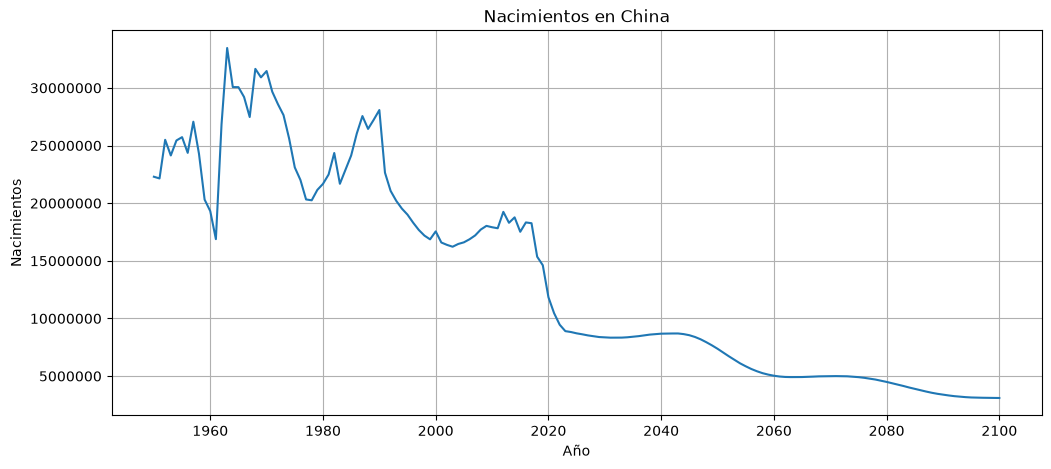

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(df_china["Year"], df_china["births"])
plt.title("Nacimientos en China")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.grid()
plt.show()

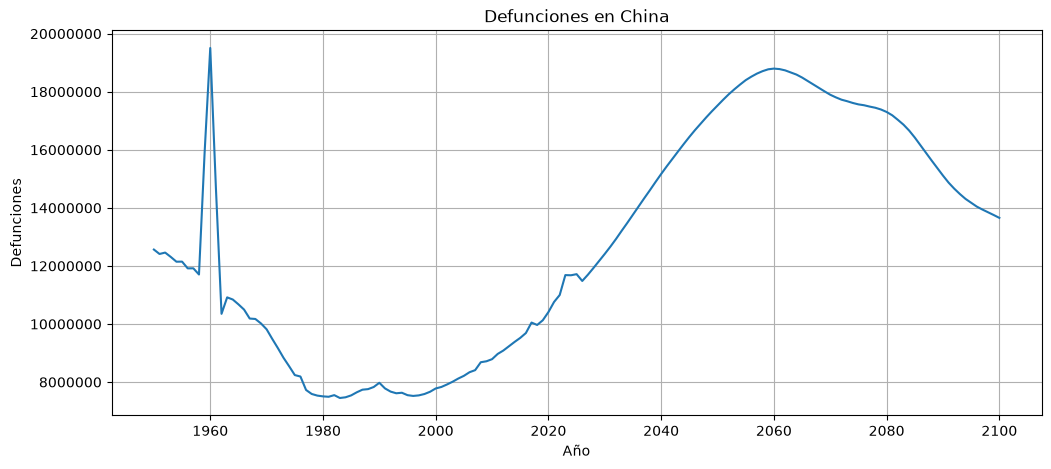

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(df_china["Year"], df_china["deaths"])
plt.title("Defunciones en China")
plt.xlabel("Año")
plt.ylabel("Defunciones")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.grid()
plt.show()

In [9]:
df_historico = df_china[df_china["Year"] <= 2023]
df_proyectado = df_china[df_china["Year"] > 2023]

print("Histórico  ->", df_historico.shape, "| años:", df_historico["Year"].min(), "a", df_historico["Year"].max())
print("Proyectado ->", df_proyectado.shape, "| años:", df_proyectado["Year"].min(), "a", df_proyectado["Year"].max())

Histórico  -> (74, 9) | años: 1950 a 2023
Proyectado -> (77, 9) | años: 2024 a 2100


In [10]:
X = df_historico[["Year"]]
y_nacimientos = df_historico["births"]

### Modelo 1 — Regresión lineal (nacimientos)

In [11]:
modelo_lineal = LinearRegression()
modelo_lineal.fit(X, y_nacimientos)

predicciones_lineal = modelo_lineal.predict(X)

anios_futuros = np.arange(2024, 2101).reshape(-1, 1)
X_futuro = pd.DataFrame(anios_futuros, columns=["Year"])

predicciones_lineal_futuras = modelo_lineal.predict(X_futuro)

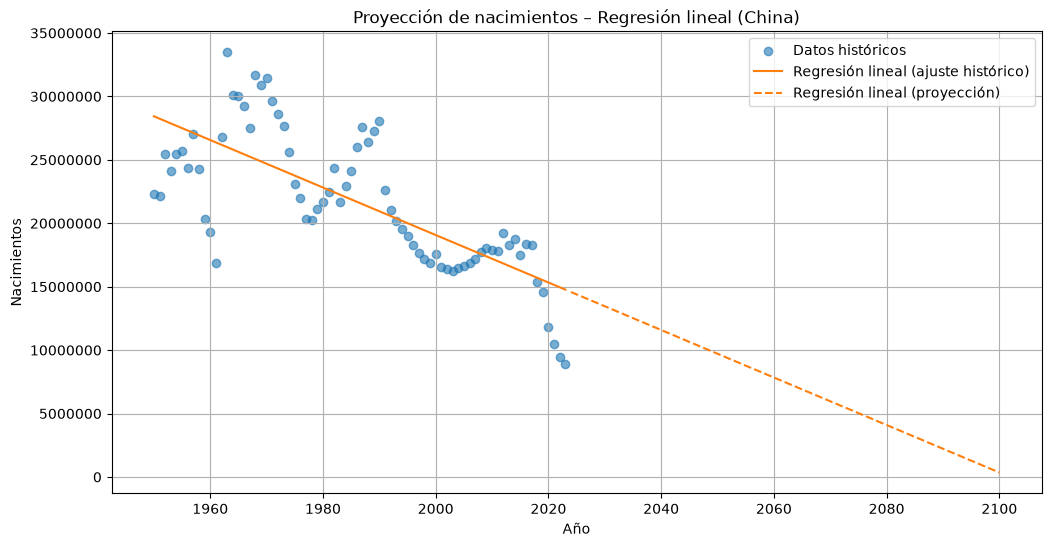

In [12]:
plt.figure(figsize=(12, 6))
plt.scatter(df_historico["Year"], df_historico["births"], label="Datos históricos", alpha=0.6)
plt.plot(df_historico["Year"], predicciones_lineal, color="tab:orange", label="Regresión lineal (ajuste histórico)")
plt.plot(anios_futuros.flatten(), predicciones_lineal_futuras, color="tab:orange", linestyle="--", label="Regresión lineal (proyección)")
plt.title("Proyección de nacimientos – Regresión lineal (China)")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Modelo 2 — Regresión polinomial (nacimientos)

In [13]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

modelo_polinomial = LinearRegression()
modelo_polinomial.fit(X_poly, y_nacimientos)

predicciones_polinomiales = modelo_polinomial.predict(X_poly)

anios_futuros_poly = poly.transform(X_futuro)
predicciones_polinomiales_futuras = modelo_polinomial.predict(anios_futuros_poly)

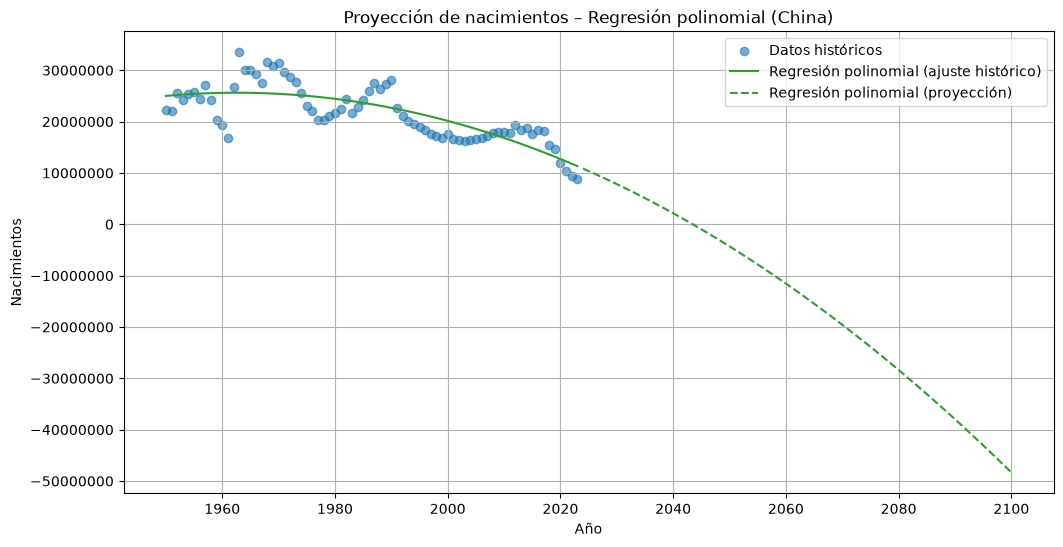

In [14]:
plt.figure(figsize=(12, 6))
plt.scatter(df_historico["Year"], df_historico["births"], label="Datos históricos", alpha=0.6)
plt.plot(df_historico["Year"], predicciones_polinomiales, color="tab:green", label="Regresión polinomial (ajuste histórico)")
plt.plot(anios_futuros.flatten(), predicciones_polinomiales_futuras, color="tab:green", linestyle="--", label="Regresión polinomial (proyección)")
plt.title("Proyección de nacimientos – Regresión polinomial (China)")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Modelo 3 — Random Forest (nacimientos)

In [15]:
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X, y_nacimientos)

predicciones_rf = modelo_rf.predict(X)
predicciones_rf_futuras = modelo_rf.predict(X_futuro)

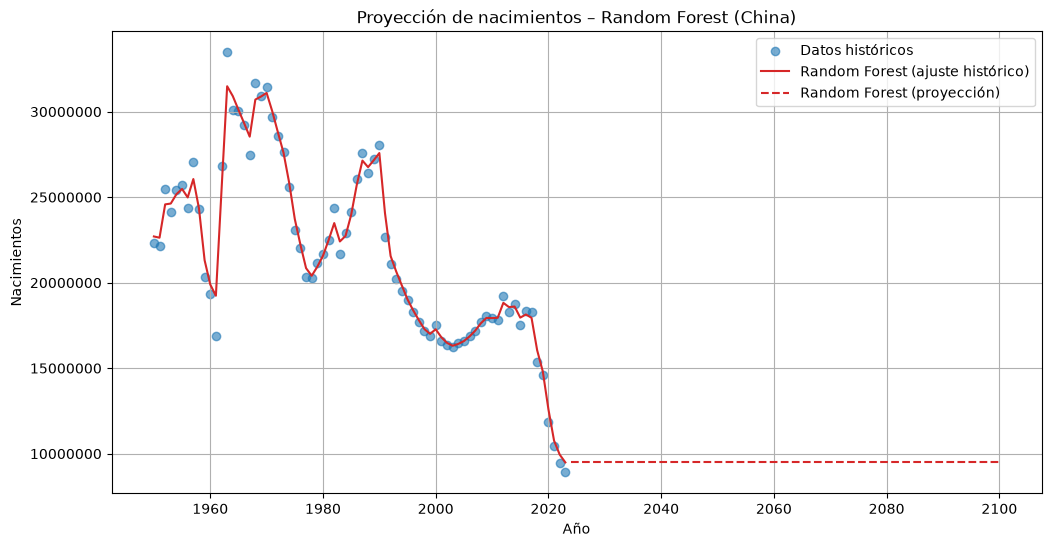

In [16]:
plt.figure(figsize=(12, 6))
plt.scatter(df_historico["Year"], df_historico["births"], label="Datos históricos", alpha=0.6)
plt.plot(df_historico["Year"], predicciones_rf, color="tab:red", label="Random Forest (ajuste histórico)")
plt.plot(anios_futuros.flatten(), predicciones_rf_futuras, color="tab:red", linestyle="--", label="Random Forest (proyección)")
plt.title("Proyección de nacimientos – Random Forest (China)")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Comparación de los 3 modelos — Nacimientos (China)

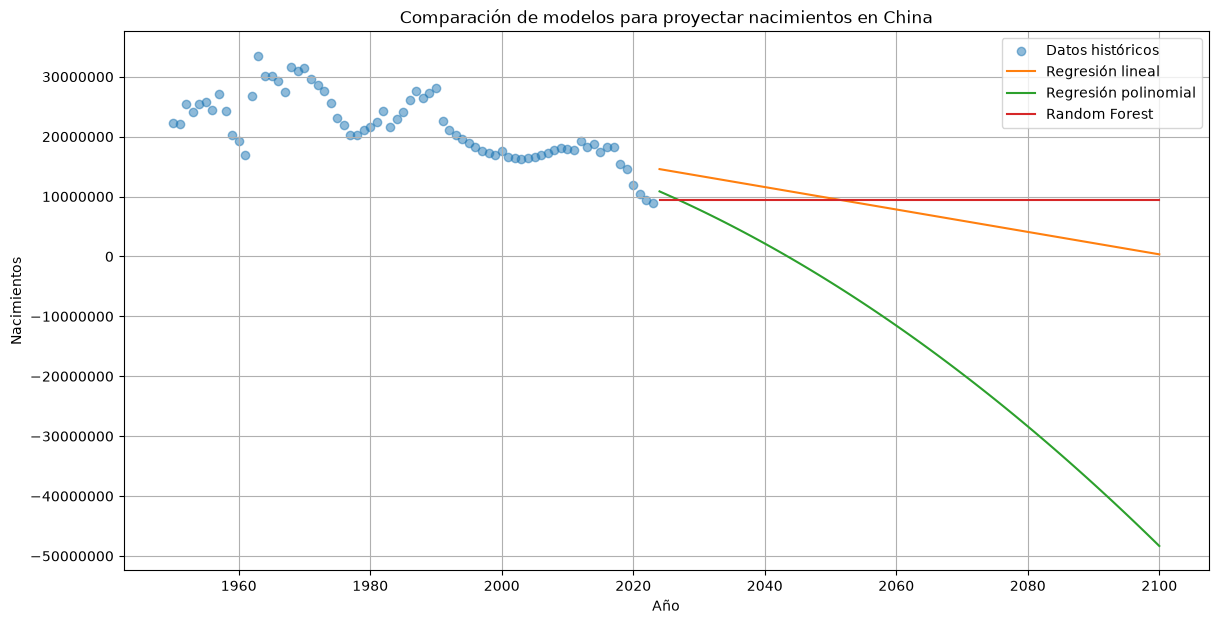

In [17]:
plt.figure(figsize=(14, 7))
plt.scatter(df_historico["Year"], df_historico["births"], label="Datos históricos", alpha=0.5)
plt.plot(anios_futuros.flatten(), predicciones_lineal_futuras, color="tab:orange", label="Regresión lineal")
plt.plot(anios_futuros.flatten(), predicciones_polinomiales_futuras, color="tab:green", label="Regresión polinomial")
plt.plot(anios_futuros.flatten(), predicciones_rf_futuras, color="tab:red", label="Random Forest")
plt.title("Comparación de modelos para proyectar nacimientos en China")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Repetir para defunciones (China)

In [18]:
y_defunciones = df_historico["deaths"]

modelo_lineal_deaths = LinearRegression()
modelo_lineal_deaths.fit(X, y_defunciones)
predicciones_lineal_deaths = modelo_lineal_deaths.predict(X_futuro)

modelo_polinomial_deaths = LinearRegression()
modelo_polinomial_deaths.fit(X_poly, y_defunciones)
predicciones_polinomiales_deaths = modelo_polinomial_deaths.predict(anios_futuros_poly)

modelo_rf_deaths = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf_deaths.fit(X, y_defunciones)
predicciones_rf_deaths = modelo_rf_deaths.predict(X_futuro)

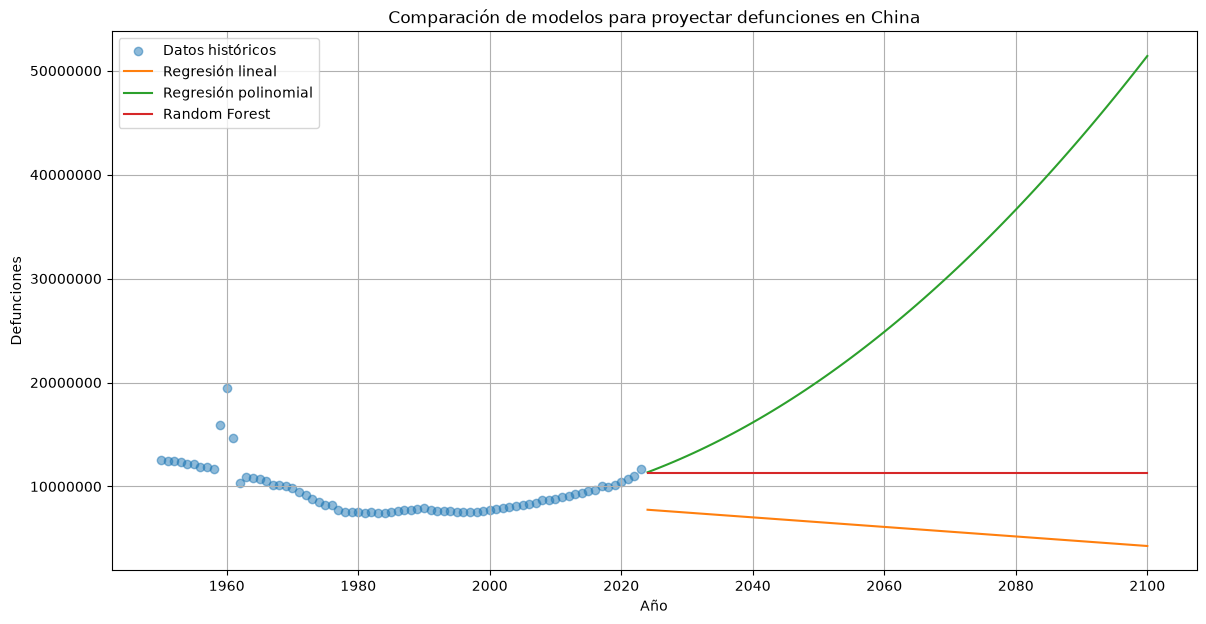

In [19]:
plt.figure(figsize=(14, 7))
plt.scatter(df_historico["Year"], df_historico["deaths"], label="Datos históricos", alpha=0.5)
plt.plot(anios_futuros.flatten(), predicciones_lineal_deaths, color="tab:orange", label="Regresión lineal")
plt.plot(anios_futuros.flatten(), predicciones_polinomiales_deaths, color="tab:green", label="Regresión polinomial")
plt.plot(anios_futuros.flatten(), predicciones_rf_deaths, color="tab:red", label="Random Forest")
plt.title("Comparación de modelos para proyectar defunciones en China")
plt.xlabel("Año")
plt.ylabel("Defunciones")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

---
# EJERCICIO 2. México — nacimientos/defunciones a partir de 1980

In [20]:
pais_mx1980 = "Mexico"

df_mx1980 = df[(df["Entity"] == pais_mx1980) & (df["Year"] >= 1980)]

df_mx1980.head()

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected,births,deaths
22831,Mexico,MEX,1980,464115.0,NaN,2357249.0,NaN,2357249.0,464115.0
22832,Mexico,MEX,1981,461670.0,NaN,2366047.0,NaN,2366047.0,461670.0
22833,Mexico,MEX,1982,462853.0,NaN,2384613.0,NaN,2384613.0,462853.0
22834,Mexico,MEX,1983,465775.0,NaN,2404958.0,NaN,2404958.0,465775.0
22835,Mexico,MEX,1984,470587.0,NaN,2431036.0,NaN,2431036.0,470587.0


In [21]:
print("Rango de años:", df_mx1980["Year"].min(), "-", df_mx1980["Year"].max())
print("Número de filas:", df_mx1980.shape[0])

Rango de años: 1980 - 2100
Número de filas: 121


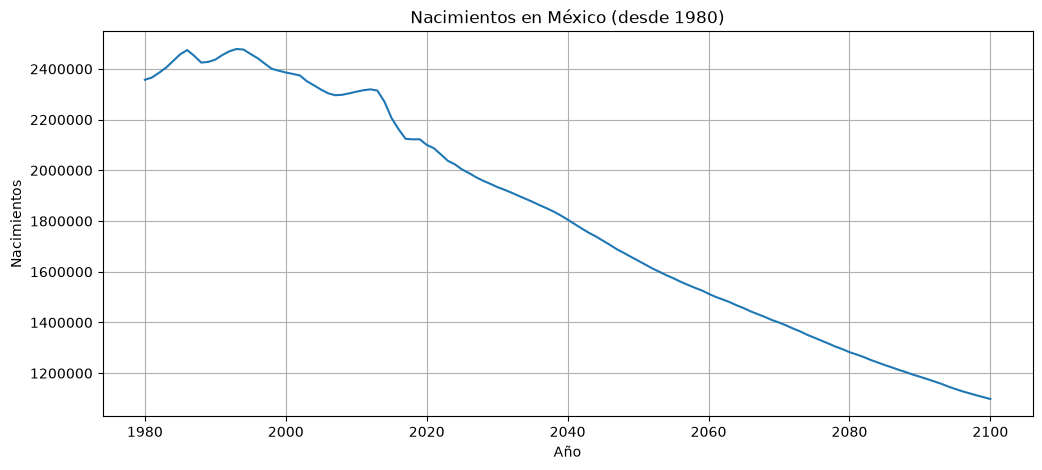

In [22]:
plt.figure(figsize=(12, 5))
plt.plot(df_mx1980["Year"], df_mx1980["births"])
plt.title("Nacimientos en México (desde 1980)")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.grid()
plt.show()

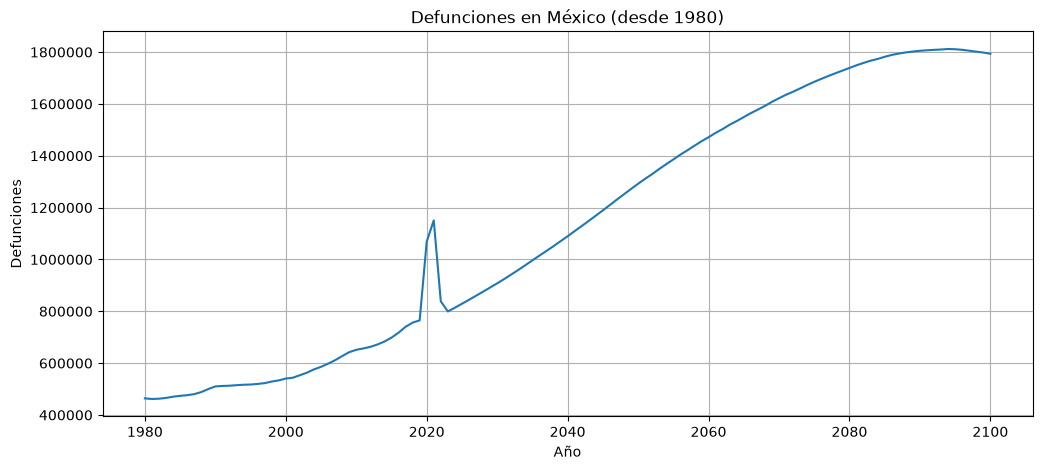

In [23]:
plt.figure(figsize=(12, 5))
plt.plot(df_mx1980["Year"], df_mx1980["deaths"])
plt.title("Defunciones en México (desde 1980)")
plt.xlabel("Año")
plt.ylabel("Defunciones")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.grid()
plt.show()

In [24]:
df_historico_mx1980 = df_mx1980[df_mx1980["Year"] <= 2023]
df_proyectado_mx1980 = df_mx1980[df_mx1980["Year"] > 2023]

print("Histórico  ->", df_historico_mx1980.shape, "| años:", df_historico_mx1980["Year"].min(), "a", df_historico_mx1980["Year"].max())
print("Proyectado ->", df_proyectado_mx1980.shape, "| años:", df_proyectado_mx1980["Year"].min(), "a", df_proyectado_mx1980["Year"].max())

Histórico  -> (44, 9) | años: 1980 a 2023
Proyectado -> (77, 9) | años: 2024 a 2100


In [25]:
X_mx1980 = df_historico_mx1980[["Year"]]
y_nacimientos_mx1980 = df_historico_mx1980["births"]

### Modelo 1 — Regresión lineal (nacimientos, México desde 1980)

In [26]:
modelo_lineal_mx1980 = LinearRegression()
modelo_lineal_mx1980.fit(X_mx1980, y_nacimientos_mx1980)

predicciones_lineal_mx1980 = modelo_lineal_mx1980.predict(X_mx1980)

anios_futuros_mx1980 = np.arange(2024, 2101).reshape(-1, 1)
X_futuro_mx1980 = pd.DataFrame(anios_futuros_mx1980, columns=["Year"])

predicciones_lineal_futuras_mx1980 = modelo_lineal_mx1980.predict(X_futuro_mx1980)

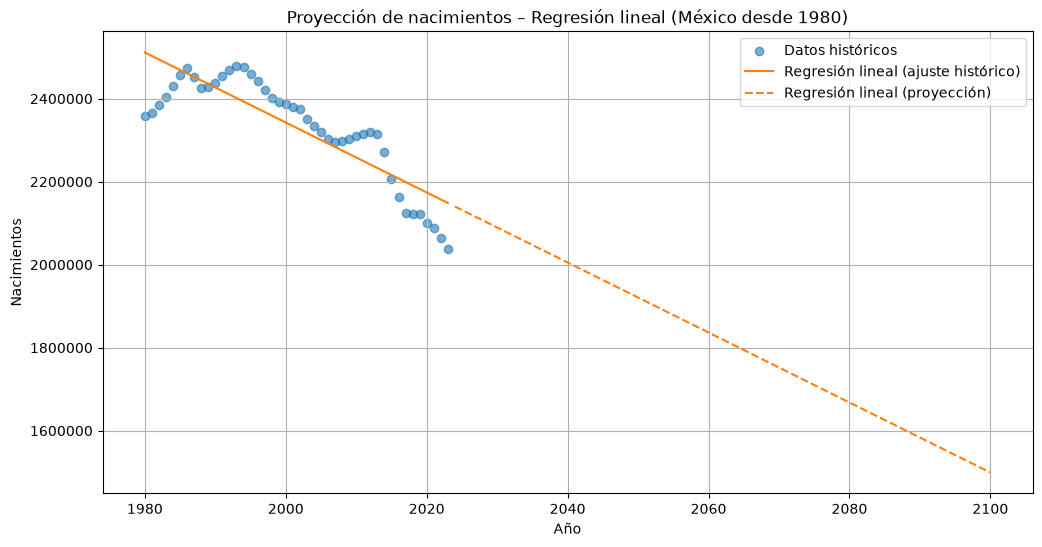

In [27]:
plt.figure(figsize=(12, 6))
plt.scatter(df_historico_mx1980["Year"], df_historico_mx1980["births"], label="Datos históricos", alpha=0.6)
plt.plot(df_historico_mx1980["Year"], predicciones_lineal_mx1980, color="tab:orange", label="Regresión lineal (ajuste histórico)")
plt.plot(anios_futuros_mx1980.flatten(), predicciones_lineal_futuras_mx1980, color="tab:orange", linestyle="--", label="Regresión lineal (proyección)")
plt.title("Proyección de nacimientos – Regresión lineal (México desde 1980)")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Modelo 2 — Regresión polinomial (nacimientos, México desde 1980)

In [28]:
poly_mx1980 = PolynomialFeatures(degree=2, include_bias=False)
X_poly_mx1980 = poly_mx1980.fit_transform(X_mx1980)

modelo_polinomial_mx1980 = LinearRegression()
modelo_polinomial_mx1980.fit(X_poly_mx1980, y_nacimientos_mx1980)

predicciones_polinomiales_mx1980 = modelo_polinomial_mx1980.predict(X_poly_mx1980)

anios_futuros_poly_mx1980 = poly_mx1980.transform(X_futuro_mx1980)
predicciones_polinomiales_futuras_mx1980 = modelo_polinomial_mx1980.predict(anios_futuros_poly_mx1980)

In [ ]:
plt.figure(figsize=(12, 6))
plt.scatter(df_historico_mx1980["Year"], df_historico_mx1980["births"], label="Datos históricos", alpha=0.6)
plt.plot(df_historico_mx1980["Year"], predicciones_polinomiales_mx1980, color="tab:green", label="Regresión polinomial (ajuste histórico)")
plt.plot(anios_futuros_mx1980.flatten(), predicciones_polinomiales_futuras_mx1980, color="tab:green", linestyle="--", label="Regresión polinomial (proyección)")
plt.title("Proyección de nacimientos – Regresión polinomial (México desde 1980)")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Modelo 3 — Random Forest (nacimientos, México desde 1980)

In [ ]:
modelo_rf_mx1980 = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf_mx1980.fit(X_mx1980, y_nacimientos_mx1980)

predicciones_rf_mx1980 = modelo_rf_mx1980.predict(X_mx1980)
predicciones_rf_futuras_mx1980 = modelo_rf_mx1980.predict(X_futuro_mx1980)

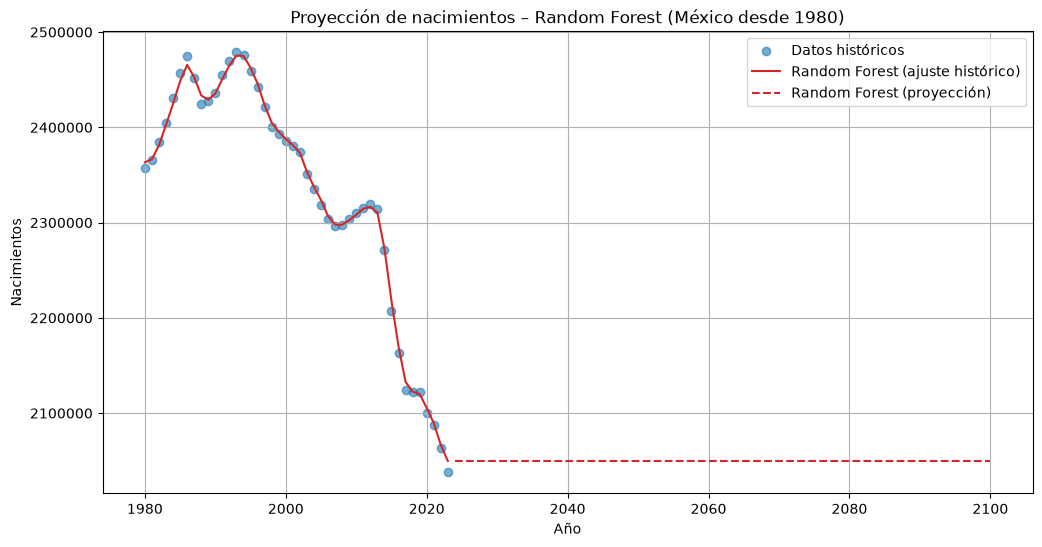

In [ ]:
plt.figure(figsize=(12, 6))
plt.scatter(df_historico_mx1980["Year"], df_historico_mx1980["births"], label="Datos históricos", alpha=0.6)
plt.plot(df_historico_mx1980["Year"], predicciones_rf_mx1980, color="tab:red", label="Random Forest (ajuste histórico)")
plt.plot(anios_futuros_mx1980.flatten(), predicciones_rf_futuras_mx1980, color="tab:red", linestyle="--", label="Random Forest (proyección)")
plt.title("Proyección de nacimientos – Random Forest (México desde 1980)")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Comparación de los 3 modelos — Nacimientos (México desde 1980)

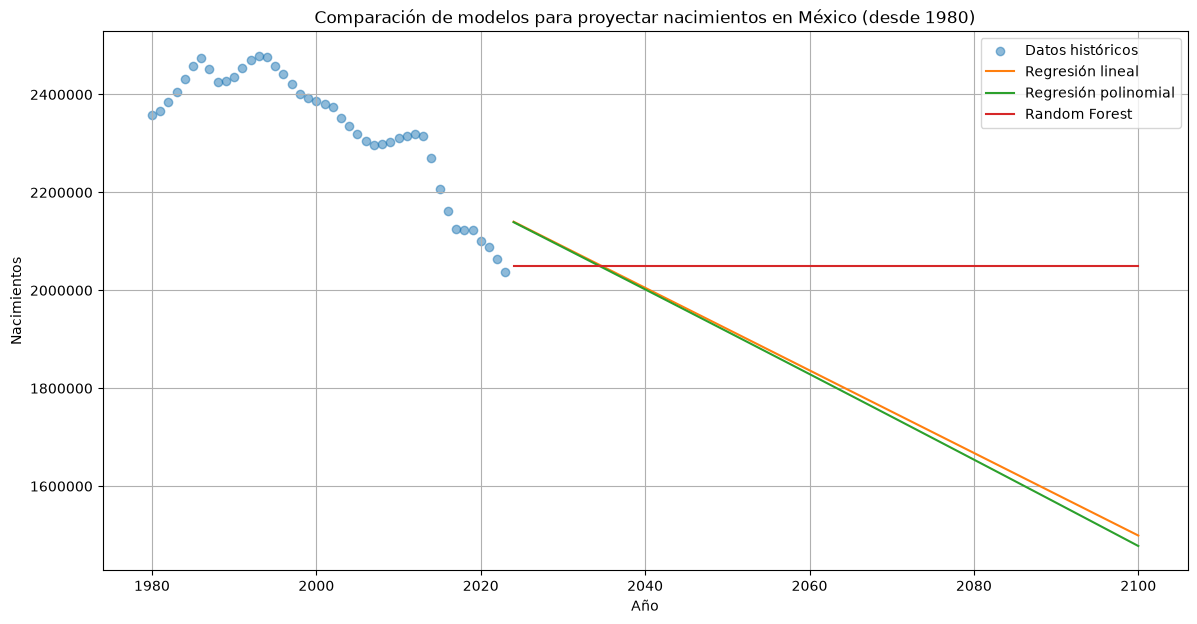

In [ ]:
plt.figure(figsize=(14, 7))
plt.scatter(df_historico_mx1980["Year"], df_historico_mx1980["births"], label="Datos históricos", alpha=0.5)
plt.plot(anios_futuros_mx1980.flatten(), predicciones_lineal_futuras_mx1980, color="tab:orange", label="Regresión lineal")
plt.plot(anios_futuros_mx1980.flatten(), predicciones_polinomiales_futuras_mx1980, color="tab:green", label="Regresión polinomial")
plt.plot(anios_futuros_mx1980.flatten(), predicciones_rf_futuras_mx1980, color="tab:red", label="Random Forest")
plt.title("Comparación de modelos para proyectar nacimientos en México (desde 1980)")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Repetir para defunciones (México desde 1980)

In [ ]:
y_defunciones_mx1980 = df_historico_mx1980["deaths"]

modelo_lineal_deaths_mx1980 = LinearRegression()
modelo_lineal_deaths_mx1980.fit(X_mx1980, y_defunciones_mx1980)
predicciones_lineal_deaths_mx1980 = modelo_lineal_deaths_mx1980.predict(X_futuro_mx1980)

modelo_polinomial_deaths_mx1980 = LinearRegression()
modelo_polinomial_deaths_mx1980.fit(X_poly_mx1980, y_defunciones_mx1980)
predicciones_polinomiales_deaths_mx1980 = modelo_polinomial_deaths_mx1980.predict(anios_futuros_poly_mx1980)

modelo_rf_deaths_mx1980 = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf_deaths_mx1980.fit(X_mx1980, y_defunciones_mx1980)
predicciones_rf_deaths_mx1980 = modelo_rf_deaths_mx1980.predict(X_futuro_mx1980)

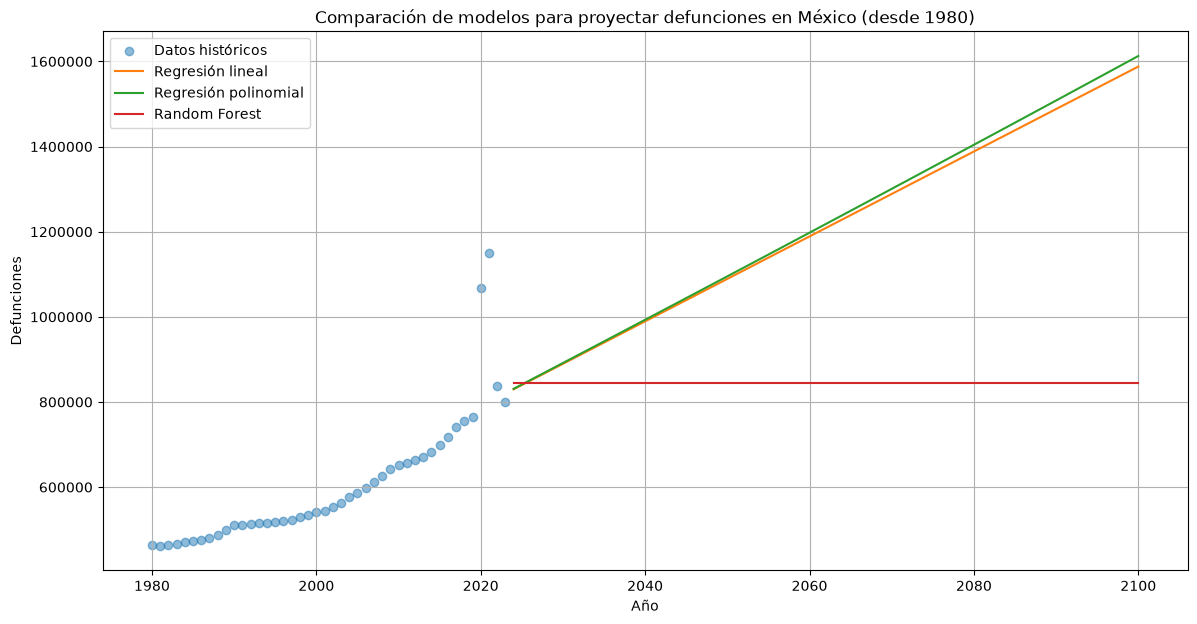

In [ ]:
plt.figure(figsize=(14, 7))
plt.scatter(df_historico_mx1980["Year"], df_historico_mx1980["deaths"], label="Datos históricos", alpha=0.5)
plt.plot(anios_futuros_mx1980.flatten(), predicciones_lineal_deaths_mx1980, color="tab:orange", label="Regresión lineal")
plt.plot(anios_futuros_mx1980.flatten(), predicciones_polinomiales_deaths_mx1980, color="tab:green", label="Regresión polinomial")
plt.plot(anios_futuros_mx1980.flatten(), predicciones_rf_deaths_mx1980, color="tab:red", label="Random Forest")
plt.title("Comparación de modelos para proyectar defunciones en México (desde 1980)")
plt.xlabel("Año")
plt.ylabel("Defunciones")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

---
# EJERCICIO 3. México — nacimientos/defunciones a partir de 2000

In [ ]:
pais_mx2000 = "Mexico"

df_mx2000 = df[(df["Entity"] == pais_mx2000) & (df["Year"] >= 2000)]

df_mx2000.head()

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected,births,deaths
22851,Mexico,MEX,2000,540567.0,NaN,2385977.0,NaN,2385977.0,540567.0
22852,Mexico,MEX,2001,543803.0,NaN,2380261.0,NaN,2380261.0,543803.0
22853,Mexico,MEX,2002,553391.0,NaN,2374140.0,NaN,2374140.0,553391.0
22854,Mexico,MEX,2003,563140.0,NaN,2351177.0,NaN,2351177.0,563140.0
22855,Mexico,MEX,2004,575925.0,NaN,2335226.0,NaN,2335226.0,575925.0


In [ ]:
print("Rango de años:", df_mx2000["Year"].min(), "-", df_mx2000["Year"].max())
print("Número de filas:", df_mx2000.shape[0])

Rango de años: 2000 - 2100
Número de filas: 101


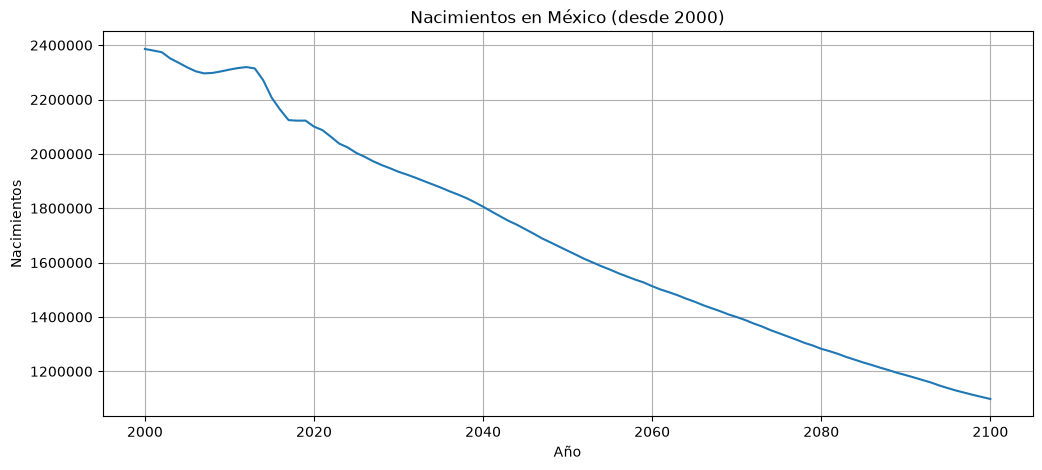

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df_mx2000["Year"], df_mx2000["births"])
plt.title("Nacimientos en México (desde 2000)")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.grid()
plt.show()

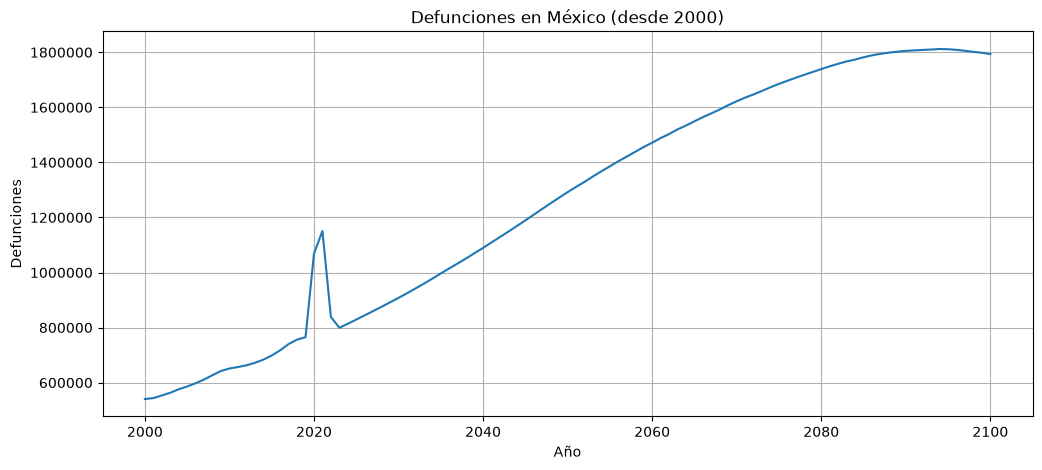

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df_mx2000["Year"], df_mx2000["deaths"])
plt.title("Defunciones en México (desde 2000)")
plt.xlabel("Año")
plt.ylabel("Defunciones")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.grid()
plt.show()

In [ ]:
df_historico_mx2000 = df_mx2000[df_mx2000["Year"] <= 2023]
df_proyectado_mx2000 = df_mx2000[df_mx2000["Year"] > 2023]

print("Histórico  ->", df_historico_mx2000.shape, "| años:", df_historico_mx2000["Year"].min(), "a", df_historico_mx2000["Year"].max())
print("Proyectado ->", df_proyectado_mx2000.shape, "| años:", df_proyectado_mx2000["Year"].min(), "a", df_proyectado_mx2000["Year"].max())

Histórico  -> (24, 9) | años: 2000 a 2023
Proyectado -> (77, 9) | años: 2024 a 2100


In [ ]:
X_mx2000 = df_historico_mx2000[["Year"]]
y_nacimientos_mx2000 = df_historico_mx2000["births"]

### Modelo 1 — Regresión lineal (nacimientos, México desde 2000)

In [ ]:
modelo_lineal_mx2000 = LinearRegression()
modelo_lineal_mx2000.fit(X_mx2000, y_nacimientos_mx2000)

predicciones_lineal_mx2000 = modelo_lineal_mx2000.predict(X_mx2000)

anios_futuros_mx2000 = np.arange(2024, 2101).reshape(-1, 1)
X_futuro_mx2000 = pd.DataFrame(anios_futuros_mx2000, columns=["Year"])

predicciones_lineal_futuras_mx2000 = modelo_lineal_mx2000.predict(X_futuro_mx2000)

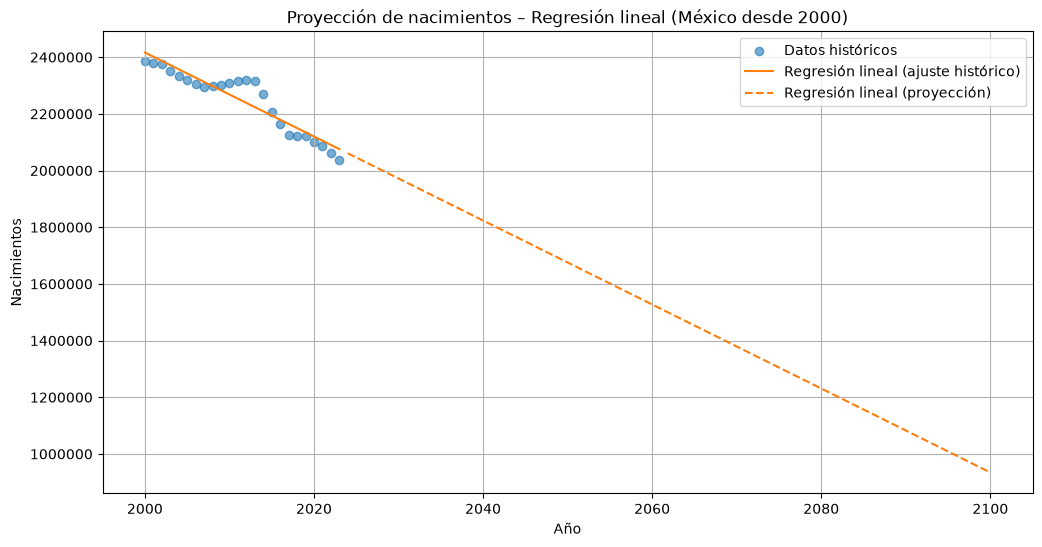

In [ ]:
plt.figure(figsize=(12, 6))
plt.scatter(df_historico_mx2000["Year"], df_historico_mx2000["births"], label="Datos históricos", alpha=0.6)
plt.plot(df_historico_mx2000["Year"], predicciones_lineal_mx2000, color="tab:orange", label="Regresión lineal (ajuste histórico)")
plt.plot(anios_futuros_mx2000.flatten(), predicciones_lineal_futuras_mx2000, color="tab:orange", linestyle="--", label="Regresión lineal (proyección)")
plt.title("Proyección de nacimientos – Regresión lineal (México desde 2000)")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Modelo 2 — Regresión polinomial (nacimientos, México desde 2000)

In [ ]:
poly_mx2000 = PolynomialFeatures(degree=2, include_bias=False)
X_poly_mx2000 = poly_mx2000.fit_transform(X_mx2000)

modelo_polinomial_mx2000 = LinearRegression()
modelo_polinomial_mx2000.fit(X_poly_mx2000, y_nacimientos_mx2000)

predicciones_polinomiales_mx2000 = modelo_polinomial_mx2000.predict(X_poly_mx2000)

anios_futuros_poly_mx2000 = poly_mx2000.transform(X_futuro_mx2000)
predicciones_polinomiales_futuras_mx2000 = modelo_polinomial_mx2000.predict(anios_futuros_poly_mx2000)

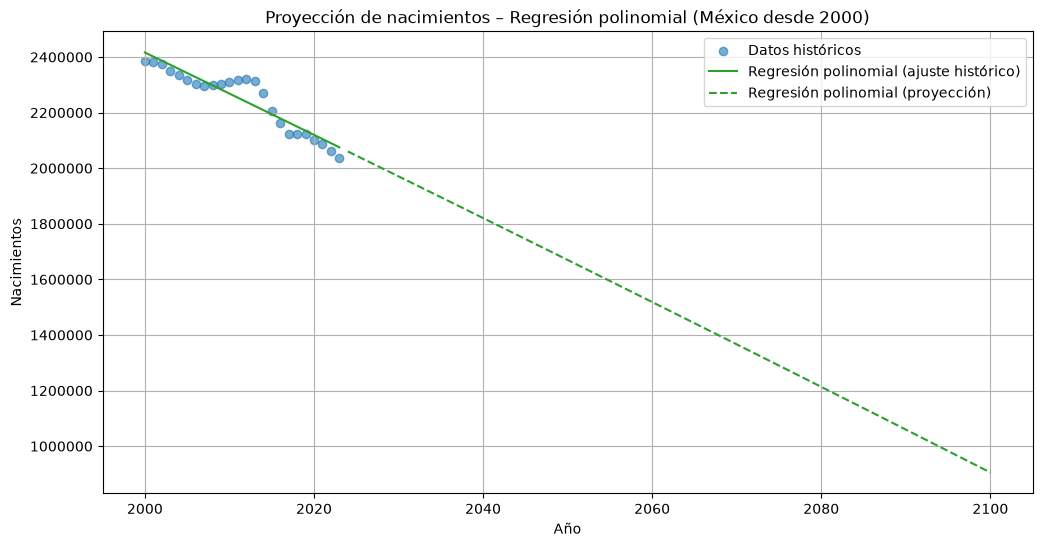

In [ ]:
plt.figure(figsize=(12, 6))
plt.scatter(df_historico_mx2000["Year"], df_historico_mx2000["births"], label="Datos históricos", alpha=0.6)
plt.plot(df_historico_mx2000["Year"], predicciones_polinomiales_mx2000, color="tab:green", label="Regresión polinomial (ajuste histórico)")
plt.plot(anios_futuros_mx2000.flatten(), predicciones_polinomiales_futuras_mx2000, color="tab:green", linestyle="--", label="Regresión polinomial (proyección)")
plt.title("Proyección de nacimientos – Regresión polinomial (México desde 2000)")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Modelo 3 — Random Forest (nacimientos, México desde 2000)

In [ ]:
modelo_rf_mx2000 = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf_mx2000.fit(X_mx2000, y_nacimientos_mx2000)

predicciones_rf_mx2000 = modelo_rf_mx2000.predict(X_mx2000)
predicciones_rf_futuras_mx2000 = modelo_rf_mx2000.predict(X_futuro_mx2000)

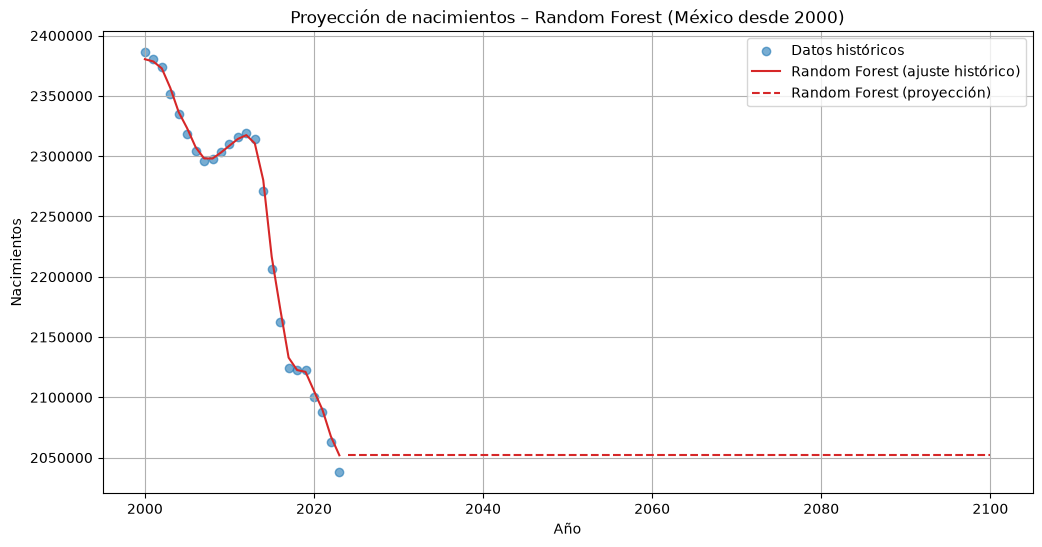

In [ ]:
plt.figure(figsize=(12, 6))
plt.scatter(df_historico_mx2000["Year"], df_historico_mx2000["births"], label="Datos históricos", alpha=0.6)
plt.plot(df_historico_mx2000["Year"], predicciones_rf_mx2000, color="tab:red", label="Random Forest (ajuste histórico)")
plt.plot(anios_futuros_mx2000.flatten(), predicciones_rf_futuras_mx2000, color="tab:red", linestyle="--", label="Random Forest (proyección)")
plt.title("Proyección de nacimientos – Random Forest (México desde 2000)")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Comparación de los 3 modelos — Nacimientos (México desde 2000)

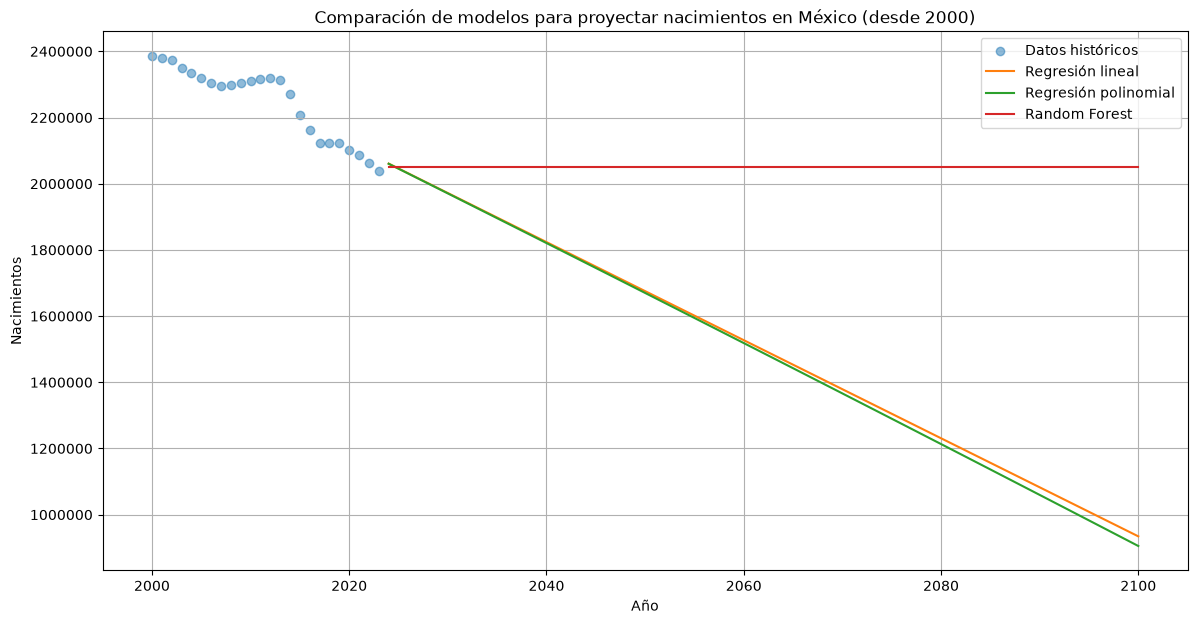

In [ ]:
plt.figure(figsize=(14, 7))
plt.scatter(df_historico_mx2000["Year"], df_historico_mx2000["births"], label="Datos históricos", alpha=0.5)
plt.plot(anios_futuros_mx2000.flatten(), predicciones_lineal_futuras_mx2000, color="tab:orange", label="Regresión lineal")
plt.plot(anios_futuros_mx2000.flatten(), predicciones_polinomiales_futuras_mx2000, color="tab:green", label="Regresión polinomial")
plt.plot(anios_futuros_mx2000.flatten(), predicciones_rf_futuras_mx2000, color="tab:red", label="Random Forest")
plt.title("Comparación de modelos para proyectar nacimientos en México (desde 2000)")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Repetir para defunciones (México desde 2000)

In [ ]:
y_defunciones_mx2000 = df_historico_mx2000["deaths"]

modelo_lineal_deaths_mx2000 = LinearRegression()
modelo_lineal_deaths_mx2000.fit(X_mx2000, y_defunciones_mx2000)
predicciones_lineal_deaths_mx2000 = modelo_lineal_deaths_mx2000.predict(X_futuro_mx2000)

modelo_polinomial_deaths_mx2000 = LinearRegression()
modelo_polinomial_deaths_mx2000.fit(X_poly_mx2000, y_defunciones_mx2000)
predicciones_polinomiales_deaths_mx2000 = modelo_polinomial_deaths_mx2000.predict(anios_futuros_poly_mx2000)

modelo_rf_deaths_mx2000 = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf_deaths_mx2000.fit(X_mx2000, y_defunciones_mx2000)
predicciones_rf_deaths_mx2000 = modelo_rf_deaths_mx2000.predict(X_futuro_mx2000)

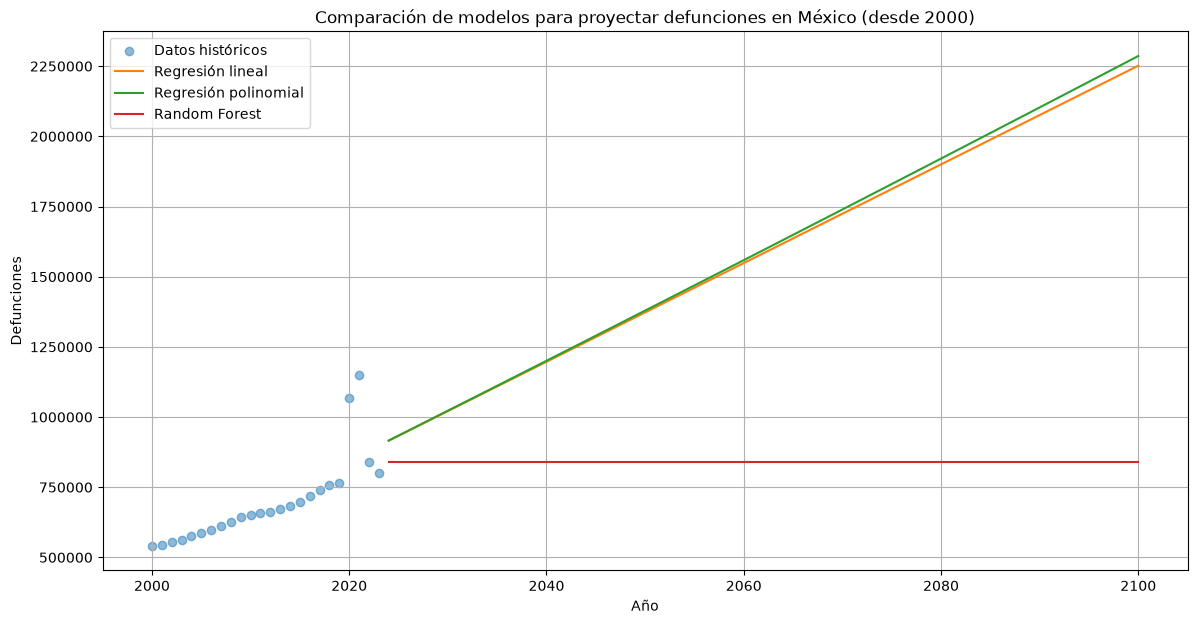

In [ ]:
plt.figure(figsize=(14, 7))
plt.scatter(df_historico_mx2000["Year"], df_historico_mx2000["deaths"], label="Datos históricos", alpha=0.5)
plt.plot(anios_futuros_mx2000.flatten(), predicciones_lineal_deaths_mx2000, color="tab:orange", label="Regresión lineal")
plt.plot(anios_futuros_mx2000.flatten(), predicciones_polinomiales_deaths_mx2000, color="tab:green", label="Regresión polinomial")
plt.plot(anios_futuros_mx2000.flatten(), predicciones_rf_deaths_mx2000, color="tab:red", label="Random Forest")
plt.title("Comparación de modelos para proyectar defunciones en México (desde 2000)")
plt.xlabel("Año")
plt.ylabel("Defunciones")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()